This notebook processes the raw data previously pulled from Snowflake, fills $0 revenue days, creates labels, and saves the processed dataset in s3. It largely follows `preprocess_pd.py`, except this notebook does not contain feature calculations, which will be in the next notebook. Because there are usually many iterations of feature engineering during experiments, I put them in a separate notebook so that I only need to change that notebook if we need to create new features from existing data.

In [1]:
""" Data preprocessing for PD model"""

import json
import os
os.chdir('../')

import numpy as np
import pandas as pd
from s3fs import S3FileSystem

from toast_cap import LOGGER
from toast_cap.utilities import config
from toast_cap.utilities.functions import (
    add_last_day_to_daily, inference_filter_accts, profile_df
)
from toast_cap.utilities.json_encoder import NpEncoder
from toast_cap.utilities.model_versioning import make_s3_dir_name
from toast_cap.utilities.pd_functions import (
    create_pd_features, 
    define_noprocessing_default, filter_censored_data
)



In [2]:
## change values in this cell depending on your requirements

run_date_str = '20250131'  # queries will pull data up to 1 day prior to run_date_str
volume_start_dt = '20200401' # pull daily revenue data starting from this date
input_dir = f's3://toast-datascience-sandbox/PradeepA/Early_Defaults/{run_date_str}' # directory to store the raw data
output = f's3://toast-datascience-sandbox/PradeepA/540_PD/{run_date_str}' # directory to store the raw data

In [3]:
# Here are the same parameters as in the function preprocess_pd_pipeline in preprocess_pd.py
# I set horizon=90 for you for the 90-day prediction horizon, and min_days_open=30 to only include restaurants with at least 30 days on platform

for_training = True
horizon = 540
default_consecutive_days = 30
min_days_open = 90
days_recent_close = 30

In [4]:
# load data
LOGGER.info('Loading data')
fs = S3FileSystem()
s3_dir_input = input_dir

df = pd.read_parquet(
    os.path.join(
#         f's3://{config.S3_BUCKET_NAME}', s3_dir_input, 'daily_data'
        s3_dir_input, 'daily_data'
    )
)
with fs.open(
    os.path.join(
        s3_dir_input, 'accts.parquet'
    ), 'rb'
) as f:
    accts = pd.read_parquet(f)
with fs.open(
    os.path.join(
       s3_dir_input,
        'monthly_modules.parquet'
    ), 'rb'
) as f:
    modules = pd.read_parquet(f)

Loading data


In [5]:
# filter accounts and columns
pd_vars = [config.GROUP, 'dt', 'totalCreditCardRevenue', 'tx_hours']

if for_training:
    file_suffix = 'train'
    # only keep restaurants with at least min_days_open days of revenue data
    filter_accts = pd.Series(
        df['dt'].max() - df.groupby(config.GROUP)['dt'].min()
    ).dt.days >= min_days_open
    filter_accts = set(filter_accts[filter_accts].index.values)
    max_days_added = 30
    
df = df.loc[df[config.GROUP].isin(filter_accts)]

In [6]:
LOGGER.info('Processing daily data for PD %s', file_suffix)
# add missing last days and fill 0 revenue days
df = add_last_day_to_daily(df, accts, max_days_added=max_days_added)
df = df.set_index('dt')\
.groupby(config.GROUP)\
.apply(lambda x: x.drop(config.GROUP,axis=1)\
    .resample('D').asfreq().fillna(0))\
.reset_index()

Processing daily data for PD train


In [7]:
if for_training:
    LOGGER.info('Creating PD labels')
    for h in [horizon]: #[90, 270, 360]:
        # the following function will create 2 new columns:
        #  'noprocessing' is a 0/1 column indicating consecutive 30-day no processing in the past 30 days leading up to the sample date
        #  'label_90' is a 0/1 column indicating the presence of a 30-day no processing window in the 90 days following the sample date
        df = define_noprocessing_default(
            df,
            horizon=h,
            default_consecutive_days=default_consecutive_days,
            revenue_var='totalCreditCardRevenue',
            pd_label=f'label_{h}'
        )

Creating PD labels


## join with other datasets

In [8]:
# accounts data
df = df.merge(accts.loc[:,['rid', 
                                 'state', 
                                 'first_order_date',
                                 'parent_market_segment',
                                 'restaurant_type', 
                                 'account_restaurant_category',
                                 'tx_date_min',
                                 'gpv_date_min',
                                'first_loan_date', 'first_loan_date_90d', 'first_loan_date_270d', 'first_loan_date_360d',
                          ]], on=['rid'])

In [9]:
## modules
monthly_modules = pd.read_parquet(os.path.join(input_dir, 'monthly_modules.parquet'))
monthly_modules.sort_values(by=['rid', 'yearmon'], inplace=True)
# for x in ['live_saas_mrr', 'live_saas_module_count']:
#     monthly_modules[f'{x}_diff_1m'] = (monthly_modules[x] - monthly_modules.groupby('rid')[x].shift().values).fillna(0)
#     monthly_modules[f'{x}_diff_2m'] = (monthly_modules[x] - monthly_modules.groupby('rid')[x].shift(2).values).fillna(0)

In [10]:
df = df.assign(yearmon=df['dt'].dt.strftime('%Y%m').astype(int))\
    .merge(monthly_modules, on=['rid', 'yearmon'], how='left')

In [11]:
df.to_parquet(os.path.join(output, 'full_raw_data.parquet'))

In [12]:
df.head(1)

,rid,dt,totalRevenue,totalCreditCardRevenue,tx_hours,noprocessing,label_540,state,first_order_date,parent_market_segment,...,gpv_date_min,first_loan_date,first_loan_date_90d,first_loan_date_270d,first_loan_date_360d,yearmon,live_online_ordering_module_count,live_saas_mrr,live_saas_module_count,live_gift_card_module_count
0,9,2020-05-26,14.64,14.64,2.0,NaN,0.0,MA,2013-07-02,SMB,...,2020-05-26,NaT,NaT,NaT,NaT,202005,0.0,60.0,6.0,0.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 127877692 entries, 0 to 127877691
Data columns (total 23 columns):
 #   Column                             Dtype         
---  ------                             -----         
 0   rid                                int64         
 1   dt                                 datetime64[ns]
 2   totalRevenue                       float64       
 3   totalCreditCardRevenue             float64       
 4   tx_hours                           float64       
 5   noprocessing                       float64       
 6   label_540                          float64       
 7   state                              object        
 8   first_order_date                   datetime64[ns]
 9   parent_market_segment              object        
 10  restaurant_type                    object        
 11  account_restaurant_category        object        
 12  tx_date_min                        datetime64[ns]
 13  gpv_date_min                       datetime64[ns]
 14

In [14]:
print('Not Default vs Default\n',df.label_540.value_counts(dropna=False))
var = round(df.label_540.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 NaN    59338548
0.0    53502050
1.0    15037094
Name: label_540, dtype: int64
The event rate is 11.76%


In [15]:
horizon=540
run_date_str = '20250131'  # queries will pull data up to 1 day prior to run_date_str
s3_output = f's3://toast-datascience-sandbox/PradeepA/Early_Defaults/{run_date_str}' # directory to store the raw data

df_loans = pd.read_parquet(f's3://toast-datascience-sandbox/PradeepA/Early_Defaults/{run_date_str}/loans.parquet') # read 'full_raw_data.parquet' generated from the previous notebook

df_capital_validation_apps = pd.read_parquet(f's3://toast-datascience-sandbox/PradeepA/Early_Defaults/{run_date_str}/capital_validation_population.parquet') # read 'full_raw_data.parquet' generated from the previous notebook


# df_defaults = pd.read_parquet(f's3://toast-datascience-sandbox/PradeepA/Early_Defaults/{run_date_str}/tc_default.parquet') # read 'full_raw_data.parquet' generated from the previous notebook

# you can add some filters to reduce the dataset you're going to work with
df = df.loc[(~df[f'label_{horizon}'].isna()) & (df['dt'].dt.year>=2018)]
df = df.sort_values(by=['rid', 'dt'])

In [16]:
df_capital_validation_apps = pd.read_parquet(f's3://toast-datascience-sandbox/PradeepA/Early_Defaults/{run_date_str}/capital_validation_population.parquet') # read 'full_raw_data.parquet' generated from the previous notebook

In [17]:
df_capital_validation_apps['rid'] = df_capital_validation_apps['rid'].astype('int64')

In [18]:
df_app_rids = df_capital_validation_apps.drop_duplicates(subset=['rid'])

In [19]:
df = pd.merge(df,df_app_rids[['rid']],on = ['rid'], how='inner')

In [20]:
df.head()

,rid,dt,totalRevenue,totalCreditCardRevenue,tx_hours,noprocessing,label_540,state,first_order_date,parent_market_segment,...,gpv_date_min,first_loan_date,first_loan_date_90d,first_loan_date_270d,first_loan_date_360d,yearmon,live_online_ordering_module_count,live_saas_mrr,live_saas_module_count,live_gift_card_module_count
0,45000000000000,2020-04-01,30.0,30.0,1.0,NaN,0.0,MA,2013-10-18,SMB,...,2020-04-01,2023-08-08,2023-08-08,NaT,NaT,202004,0.0,150.0,4.0,1.0
1,45000000000000,2020-04-02,0.0,0.0,0.0,NaN,0.0,MA,2013-10-18,SMB,...,2020-04-01,2023-08-08,2023-08-08,NaT,NaT,202004,0.0,150.0,4.0,1.0
2,45000000000000,2020-04-03,0.0,0.0,0.0,NaN,0.0,MA,2013-10-18,SMB,...,2020-04-01,2023-08-08,2023-08-08,NaT,NaT,202004,0.0,150.0,4.0,1.0
3,45000000000000,2020-04-04,0.0,0.0,0.0,NaN,0.0,MA,2013-10-18,SMB,...,2020-04-01,2023-08-08,2023-08-08,NaT,NaT,202004,0.0,150.0,4.0,1.0
4,45000000000000,2020-04-05,0.0,0.0,0.0,NaN,0.0,MA,2013-10-18,SMB,...,2020-04-01,2023-08-08,2023-08-08,NaT,NaT,202004,0.0,150.0,4.0,1.0


In [21]:
# df['yyyymmdd'] = df['dt'].dt.strftime('%Y%m%d').astype(int)
df['yyyymmdd'] = pd.to_datetime(df.dt,format="%Y%m%d")

df_capital_validation_apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58887 entries, 0 to 58886
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   entity_identifier       58887 non-null  object        
 1   rid                     58887 non-null  int64         
 2   funding_requested_date  58887 non-null  datetime64[ns]
 3   term                    58887 non-null  int64         
 4   IS_PRE_90               58887 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(1)
memory usage: 1.9+ MB


In [22]:
print('Not Default vs Default\n',df.label_540.value_counts(dropna=False))
var = round(df.label_540.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 0.0    7981226
1.0    1456164
Name: label_540, dtype: int64
The event rate is 15.43%


In [23]:
df_apps = pd.merge(df,df_capital_validation_apps[['rid','funding_requested_date','entity_identifier',"IS_PRE_90"]],left_on=['rid','dt'],right_on=['rid','funding_requested_date'], how='inner')
df_apps.shape

(13492, 27)

In [24]:
df_apps.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13492 entries, 0 to 13491
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   rid                                13492 non-null  int64         
 1   dt                                 13492 non-null  datetime64[ns]
 2   totalRevenue                       13492 non-null  float64       
 3   totalCreditCardRevenue             13492 non-null  float64       
 4   tx_hours                           13492 non-null  float64       
 5   noprocessing                       13492 non-null  float64       
 6   label_540                          13492 non-null  float64       
 7   state                              13492 non-null  object        
 8   first_order_date                   13492 non-null  datetime64[ns]
 9   parent_market_segment              13492 non-null  object        
 10  restaurant_type                   

In [25]:
df_apps['application_yyyymm'] = df_apps['funding_requested_date'].astype(str).str[:7].str.replace('-', '')

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.pylab import rcParams
import itertools
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report, \
confusion_matrix, mean_squared_error, balanced_accuracy_score,roc_curve,auc

def exp_vs_act_date(df, date, target):
    non_events = pd.DataFrame(df[df[target] == 0].groupby([date], dropna=False)[target].count()).rename(columns={target: 'non_events'})
    non_events_total = df[df[target] == 0].groupby([target], dropna=False)[target].count()
    events = pd.DataFrame(df[df[target] == 1].groupby([date], dropna=False)[target].count()).rename(columns={target: 'events'})
    events_total = df[df[target] == 1].groupby([target], dropna=False)[target].count()
    grand_total = df[target].count()
    result = pd.merge(non_events, events, how="left", on=date)

    result['total'] = result['non_events'] + result['events']
    result['act_event_rate'] = round(result['events'] / result['total'], 3)
    result['% event dist'] = result['events'] / (events_total.values)
    result['% non-event dist'] = result['non_events'] / (non_events_total.values)
    result['% total dist'] = round(result['total'] / grand_total * 100, 1)

    # Round off the decimal places for better display
    result['% event dist'] = round(result['% event dist'] * 100, 1)
    result['% non-event dist'] = round(result['% non-event dist'] * 100, 1)

    # Convert index (date) to column
    result.reset_index(inplace=True)

    # Replace nan with "Missing"
    result[date] = result[date].replace(np.nan, 'Missing', regex=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    result.plot(x=date, y=['act_event_rate'], color=['red'], marker="*", ax=ax, title='Actual 540D Default Rate Application yyyymm')
    ax.set_xticks(range(len(result)))
    ax.set_ylabel("event_rate")
    ax.set_xticklabels([item for item in result[date].tolist()], rotation=90)

In [27]:
df_apps.IS_PRE_90.value_counts(dropna=False)

False    13492
Name: IS_PRE_90, dtype: int64

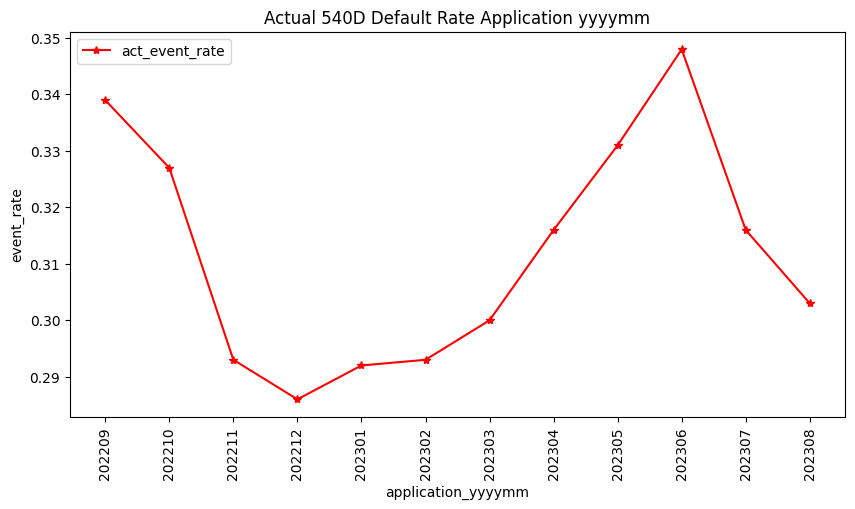

In [28]:
target = 'label_540'
score = 'y_pred'
date = 'application_yyyymm'

exp_vs_act_date(df_apps,date,target)

In [29]:
df_apps.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13492 entries, 0 to 13491
Data columns (total 28 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   rid                                13492 non-null  int64         
 1   dt                                 13492 non-null  datetime64[ns]
 2   totalRevenue                       13492 non-null  float64       
 3   totalCreditCardRevenue             13492 non-null  float64       
 4   tx_hours                           13492 non-null  float64       
 5   noprocessing                       13492 non-null  float64       
 6   label_540                          13492 non-null  float64       
 7   state                              13492 non-null  object        
 8   first_order_date                   13492 non-null  datetime64[ns]
 9   parent_market_segment              13492 non-null  object        
 10  restaurant_type                   

In [30]:
df_apps_rids = df_loans.drop_duplicates(subset=['rid'])